# Conformal Prediction Results
Visualise point predictions + uncertainty intervals for all baseline models.

**References**
- Shafer & Vovk (2008) *A Tutorial on Conformal Prediction*, JMLR 9, 371-421
- Tibshirani (2023) *Conformal Prediction*, Advanced Topics in Statistical Learning

**Metrics used (from the papers)**
- **Empirical coverage** - fraction of test points where `y_true ∈ [lower, upper]`; should be ≥ 1-alpha (eq. 12, Tibshirani)
- **Average interval width** - mean(upper - lower); smaller = more efficient (Section 2.1, Tibshirani)

## Imports & config

In [1]:
import ast
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dill

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from configs.data_constants_config import ALPHA


ALPHA = ALPHA          
NOMINAL = 1 - ALPHA    # 0.90 means 90 % coverage

print(f'Nominal coverage target: {NOMINAL:.0%}')

Nominal coverage target: 90%


## 1 · Load artefacts

In [4]:
#Data loading
path = '/home/isha/Desktop/Projects/03_Remaining_Useful_Life_Prediction/artifacts/'
X_train = pd.read_csv(os.path.join(path, 'X_train_proper.csv'))
y_train = pd.read_csv(os.path.join(path, 'y_train_proper.csv')).values.ravel()
X_cal = pd.read_csv(os.path.join(path, 'X_cal.csv'))
y_cal = pd.read_csv(os.path.join(path, 'y_cal.csv')).values.ravel()
X_test = pd.read_csv(os.path.join(path, 'X_test_processed.csv'))
y_test = pd.read_csv(os.path.join(path, 'y_test.csv')).values.ravel()

#Top 5 models after hyperparameter tuning
top5_df = pd.read_csv(os.path.join(path, 'top5_models.csv'))

print('Top-5 models (ranked by RMSE - MAE - R square):')
display(top5_df[['model','test_rmse','test_mae','test_r2','best_params']])

Top-5 models (ranked by RMSE - MAE - R square):


,model,test_rmse,test_mae,test_r2,best_params
0,XGBRegressor,16.417646,11.563441,0.832154,"{'learning_rate': 0.1, 'n_estimators': 32}"
1,Random Forest,16.427604,11.676211,0.831950,{'n_estimators': 256}
2,SVR,18.880580,12.901263,0.778016,"{'C': 1, 'degree': 2, 'kernel': 'rbf'}"
3,Linear Regression,20.826446,16.636081,0.729902,{}


## 2 · Refit top-5 models with their best hyperparameters

In [5]:
MODEL_CLASSES = {
    'Linear Regression': LinearRegression,
    'Random Forest': RandomForestRegressor,
    'SVR': SVR,
    'XGBRegressor': XGBRegressor,
}

fitted_models = {}
for _, row in top5_df.iterrows():
    name   = row['model']
    params = ast.literal_eval(row['best_params']) if row['best_params'] else {}
    model  = MODEL_CLASSES[name](**params)
    model.fit(X_train, y_train)
    fitted_models[name] = model
    print(f' Fitted: {name} with params={params}')

 Fitted: XGBRegressor with params={'learning_rate': 0.1, 'n_estimators': 32}
 Fitted: Random Forest with params={'n_estimators': 256}
 Fitted: SVR with params={'C': 1, 'degree': 2, 'kernel': 'rbf'}
 Fitted: Linear Regression with params={}


## 3 · Run conformal calibration + prediction

For each model:
1. Residuals on calibration set: $R_i = |y_i - \hat{y}_i|$
2. Quantile: $\hat{q} = $ the $\lceil (1-\alpha)(n+1) \rceil / n$ quantile of $R_1,\ldots,R_n$ (eq. 6/7, Tibshirani)
3. Interval: $\hat{C}(x) = [\hat{f}(x) - \hat{q},\; \hat{f}(x) + \hat{q}]$ (eq. 11, Tibshirani)

In [6]:
n_cal  = len(y_cal)
level  = min(np.ceil((1 - ALPHA) * (n_cal + 1)) / n_cal, 1.0)
print(f'Calibration set size n = {n_cal}')
print(f'Quantile level used = {level:.4f}  (finite-sample correction)')

results = []   #One dict per model

for name, model in fitted_models.items():
    #Calibration residuals 
    residuals = np.abs(y_cal - model.predict(X_cal))
    q_hat = np.quantile(residuals, level)

    #Test intervals 
    y_hat  = model.predict(X_test)
    lower  = y_hat - q_hat
    upper  = y_hat + q_hat

    #Mtrics (eq. 12) 
    covered   = (y_test >= lower) & (y_test <= upper)
    coverage  = covered.mean()
    avg_width = (upper - lower).mean()

    results.append({
        'model': name,
        'q_hat': q_hat,
        'coverage':  coverage,
        'avg_width': avg_width,
        '_y_hat': y_hat,
        '_lower': lower,
        '_upper': upper,
    })

res_df = pd.DataFrame(results)
#Valid models first (coverage >= nominal), then narrowest
res_df['_valid'] = res_df['coverage'] >= NOMINAL
res_df = res_df.sort_values(['_valid','avg_width'], ascending=[False,True]).reset_index(drop=True)

display(res_df[['model','q_hat','coverage','avg_width','_valid']]
        .rename(columns={'_valid':'meets_coverage_guarantee'}))

Calibration set size n = 3852
Quantile level used = 0.9003  (finite-sample correction)


,model,q_hat,coverage,avg_width,meets_coverage_guarantee
0,XGBRegressor,31.210019,0.92,62.420038,True
1,Random Forest,31.743356,0.92,63.486711,True
2,Linear Regression,36.365648,0.94,72.731296,True
3,SVR,34.800409,0.89,69.600819,False


## 4. Plot 1: Point predictions + intervals per model
Test samples sorted by `y_true`. **Green** bars = covered, **red** = missed.

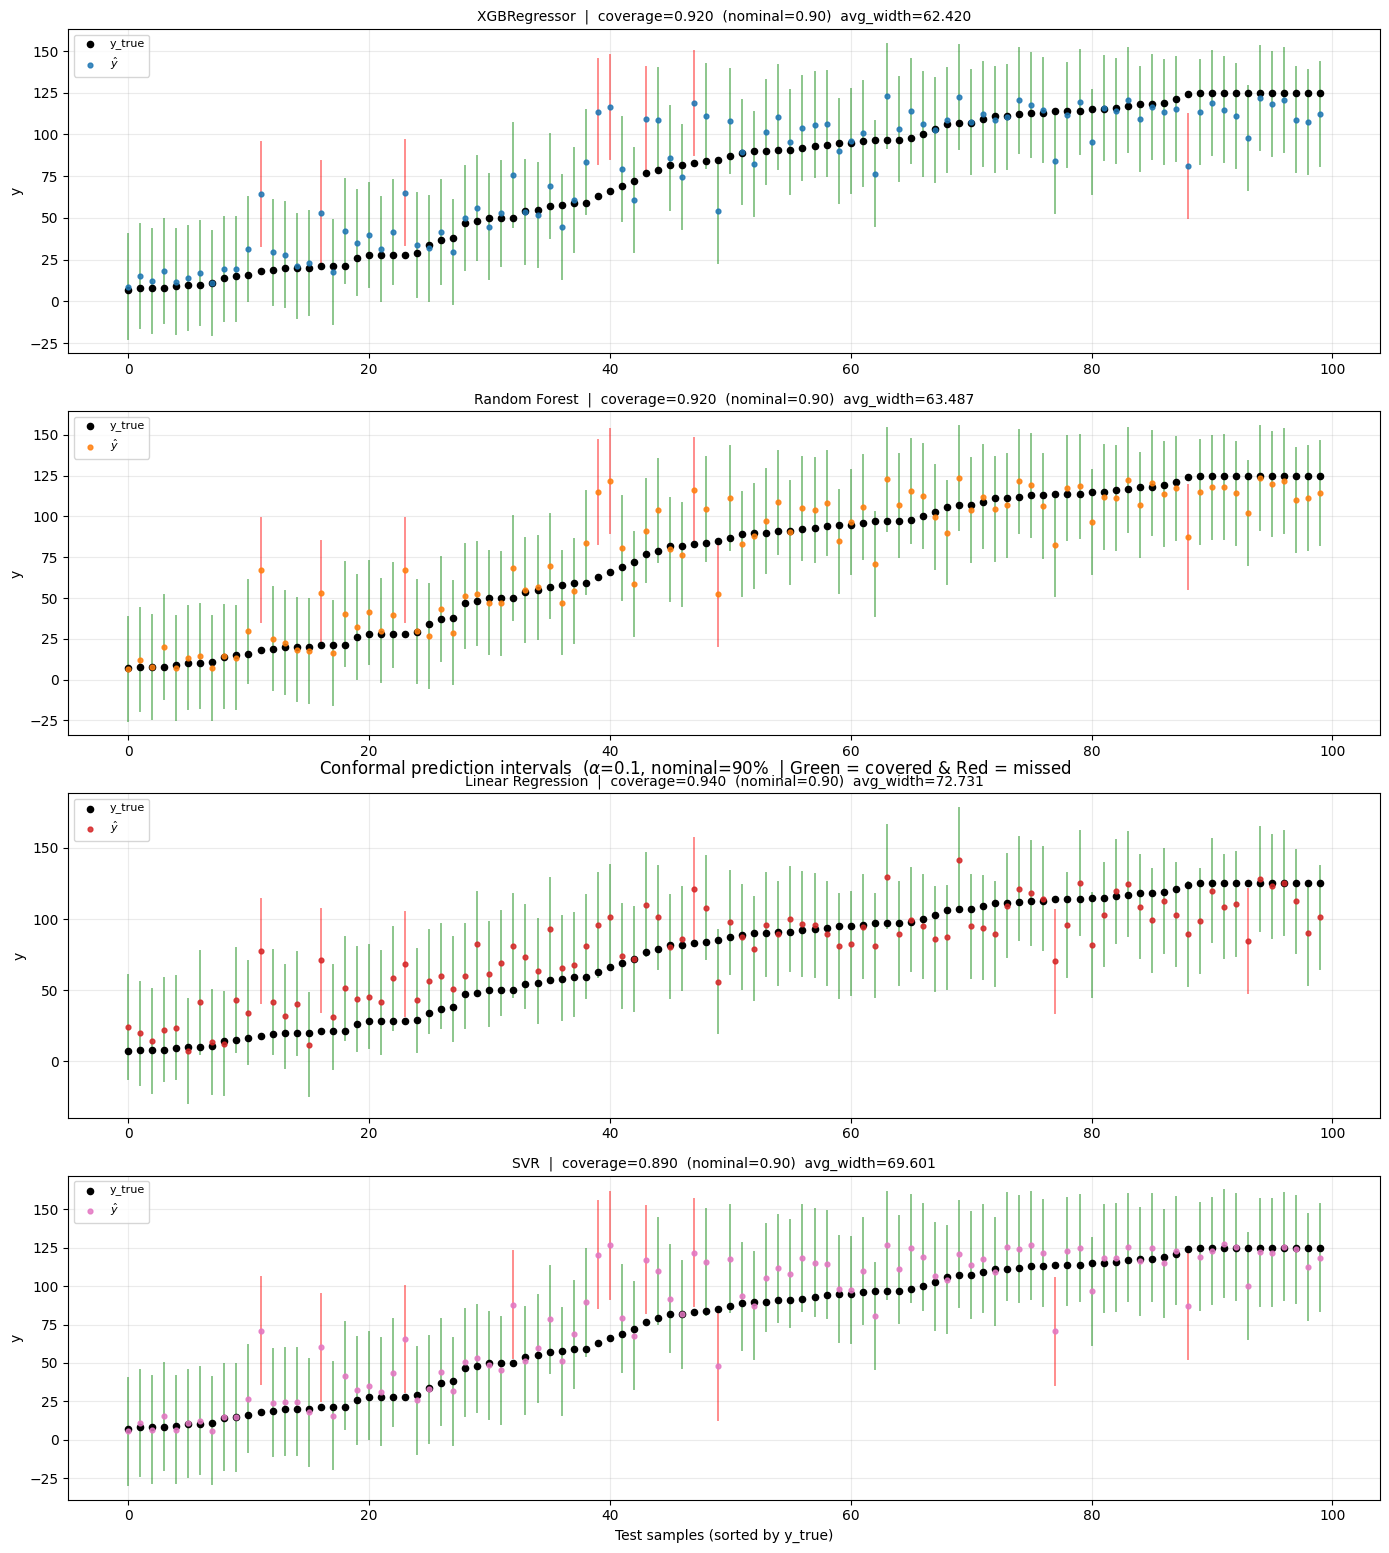

In [10]:
MAX_POINTS = 80
sort_idx  = np.argsort(y_test)
step = max(1, len(y_test) // MAX_POINTS)
idx = sort_idx[::step]
y_sub = y_test[idx]
x_pos = np.arange(len(idx))

n_models = len(res_df)
colors = plt.cm.tab10(np.linspace(0, 0.6, n_models))

fig, axes = plt.subplots(n_models, 1, figsize=(14, 4 * n_models), sharex=False)
if n_models == 1:
    axes = [axes]

for ax, (_, row), color in zip(axes, res_df.iterrows(), colors):
    lo = row['_lower'][idx]
    hi = row['_upper'][idx]
    pt = row['_y_hat'][idx]
    covered = (y_sub >= lo) & (y_sub <= hi)

    for xi, l, h, cov in zip(x_pos, lo, hi, covered):
        ax.plot([xi, xi], [l, h],
                color ='green' if cov else 'red',
                alpha = 0.45, linewidth = 1.4)

    ax.scatter(x_pos, y_sub, s = 20, color = 'black', zorder = 3, label='y_true')
    ax.scatter(x_pos, pt, s = 12, color = color, zorder = 4, alpha = 0.85, label=rf'$\hat{{y}}$')
    ax.set_title(
        f"{row['model']}  |  coverage={row['coverage']:.3f}  "
        f"(nominal={NOMINAL:.2f})  avg_width={row['avg_width']:.3f}",
        fontsize=10)
    ax.set_ylabel('y')
    ax.legend(fontsize = 8, loc='upper left')
    ax.grid(True, alpha = 0.25)

axes[-1].set_xlabel('Test samples (sorted by y_true)')
fig.suptitle(
    rf"Conformal prediction intervals  ($\alpha$={ALPHA}, nominal={NOMINAL:.0%}  | Green = covered & Red = missed",
    fontsize=12, y = 0.5)
plt.tight_layout()
plt.savefig(os.path.join(path, 'conformal_prediction_intervals.png'), dpi=300, bbox_inches='tight')
plt.show()

## 5. Plot 2: Empirical coverage vs nominal target

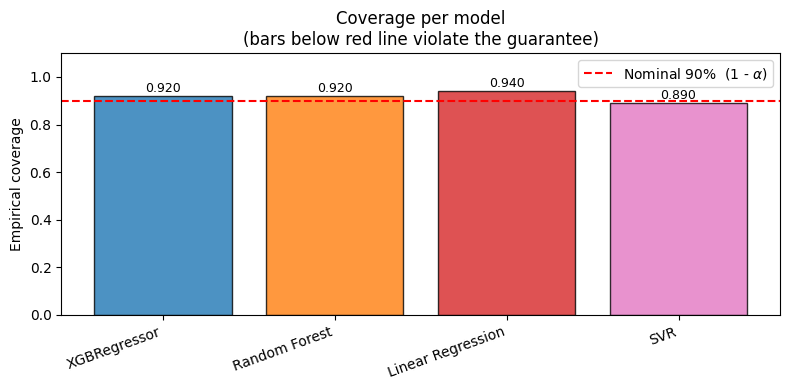

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(res_df['model'], res_df['coverage'],
              color=colors, alpha=0.8, edgecolor='black')
ax.axhline(NOMINAL, color='red', linestyle='--', linewidth=1.5,
           label=rf'Nominal {NOMINAL:.0%}  (1 - $\alpha$)')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Empirical coverage')
ax.set_title('Coverage per model\n(bars below red line violate the guarantee)')
ax.legend()
for bar, val in zip(bars, res_df['coverage']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(path, 'empirical_coverage_vs_nominal_target_per_model.png'), dpi=300, bbox_inches='tight')
plt.show()

## 6. Plot 3; Width vs Coverage  (efficiency / validity tradeoff)
**Valid** = right of red line (coverage ≥ nominal). Among valid models, **lower width = better**.

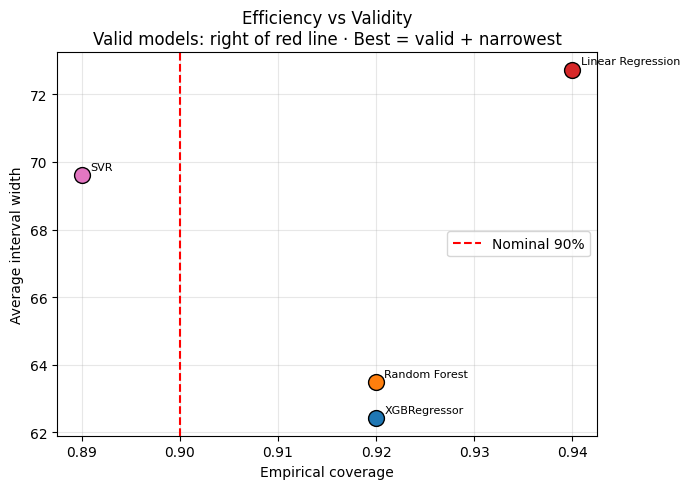

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
for i, (_, row) in enumerate(res_df.iterrows()):
    ax.scatter(row['coverage'], row['avg_width'],
               s=130, color=colors[i], edgecolors='black', zorder=3)
    ax.annotate(row['model'], (row['coverage'], row['avg_width']),
                textcoords='offset points', xytext=(6, 4), fontsize=8)

ax.axvline(NOMINAL, color='red', linestyle='--', linewidth=1.5,
           label=f'Nominal {NOMINAL:.0%}')
ax.set_xlabel('Empirical coverage')
ax.set_ylabel('Average interval width')
ax.set_title('Efficiency vs Validity\nValid models: right of red line · Best = valid + narrowest')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(path, 'efficiency_vs_validity_per_model.png'), dpi=300, bbox_inches='tight')
plt.show()

## 7. Summary table

In [17]:
summary = res_df[['model','q_hat','coverage','avg_width','_valid']].copy()
summary = summary.rename(columns={'_valid': 'meets_guarantee'})
summary['meets_guarantee'] = summary['meets_guarantee'].map({True: 'T', False: 'F'})
summary['coverage_gap'] = (summary['coverage'] - NOMINAL).round(3)

print(rf'Nominal coverage = {NOMINAL:.0%}  (alpha = {ALPHA})')
print(f'Calibration set size = {n_cal}')
print(f'Test set size = {len(y_test)}\n')


Nominal coverage = 90%  (alpha = 0.1)
Calibration set size = 3852
Test set size = 100



In [15]:
summary

,model,q_hat,coverage,avg_width,meets_guarantee,coverage_gap
0,XGBRegressor,31.210019,0.92,62.420038,T,0.02
1,Random Forest,31.743356,0.92,63.486711,T,0.02
2,Linear Regression,36.365648,0.94,72.731296,T,0.04
3,SVR,34.800409,0.89,69.600819,F,-0.01
